In [7]:
import akshare as ak
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings

# 忽略一些akshare可能产生的未来版本警告，使输出更整洁
warnings.filterwarnings('ignore')

def run_akshare_permanent_portfolio_backtest():
    """
    使用 akshare 数据执行中国版永久投资组合的量化回测。
    """
    # --- 1. 定义资产和参数 ---
    assets_etf = {
        'stocks': '513100',      # 沪深300 ETF
        'bonds': '511260',       # 10年期国债ETF
        'gold': '518880',        # 华安黄金ETF
        'cash': '511990'         # 华宝添益 (货币基金ETF)
    }
    benchmark_symbol = '000300' # 沪深300指数 (上证)
    start_date = '20150101'
    end_date = '20250922' # 您可以修改为您希望的结束日期
    initial_weights = [0.25, 0.25, 0.25, 0.25]

    # --- 2. 获取数据 ---
    print("正在从 akshare 获取数据...")
    all_prices = []
    
    # 获取ETF数据
    for name, symbol in assets_etf.items():
        try:
            etf_hist_df = ak.fund_etf_hist_em(symbol=symbol, period="daily", start_date=start_date, end_date=end_date, adjust="hfq")
            etf_hist_df = etf_hist_df[['日期', '收盘']]
            etf_hist_df.columns = ['Date', name]
            etf_hist_df['Date'] = pd.to_datetime(etf_hist_df['Date'])
            etf_hist_df.set_index('Date', inplace=True)
            all_prices.append(etf_hist_df)
            print(f"成功获取 {name} ({symbol}) 的数据。")
        except Exception as e:
            print(f"获取ETF数据失败: {name} ({symbol}). 错误: {e}")
            return

    # 获取基准指数数据
    try:
        benchmark_hist_df = ak.index_zh_a_hist(symbol=benchmark_symbol, period="daily", start_date=start_date, end_date=end_date)
        benchmark_hist_df = benchmark_hist_df[['日期', '收盘']]
        benchmark_hist_df.columns = ['Date', 'benchmark']
        benchmark_hist_df['Date'] = pd.to_datetime(benchmark_hist_df['Date'])
        benchmark_hist_df.set_index('Date', inplace=True)
        all_prices.append(benchmark_hist_df)
        print(f"成功获取基准指数 {benchmark_symbol} 的数据。")
    except Exception as e:
        print(f"获取基准指数数据失败: {benchmark_symbol}. 错误: {e}")
        return
        
    # 合并数据
    data = pd.concat(all_prices, axis=1)
    data['cash'].fillna(method='ffill', inplace=True) # 货币基金净值在非交易日可能为空，用前值填充
    data.dropna(inplace=True)
    print("数据合并处理成功。")

    monthly_returns = data.resample('M').last().pct_change().dropna()

    # --- 3. 构建策略回报序列 ---
    portfolio_returns = []
    rebalance_dates = monthly_returns.resample('A').last().index
    current_weights = pd.Series(initial_weights, index=assets_etf.keys())

    for date, row in monthly_returns.iterrows():
        if date in rebalance_dates:
            current_weights = pd.Series(initial_weights, index=assets_etf.keys())
        
        month_return = (row[assets_etf.keys()] * current_weights).sum()
        portfolio_returns.append(month_return)
        
        new_asset_values = current_weights * (1 + row[assets_etf.keys()])
        current_weights = new_asset_values / new_asset_values.sum()

    portfolio_returns_df = pd.DataFrame({
        'Permanent Portfolio': portfolio_returns,
        'Benchmark': monthly_returns['benchmark'].values
    }, index=monthly_returns.index)

    # --- 4. 计算并输出性能指标 ---
    def calculate_performance_metrics(returns_df):
        metrics = {}
        for col in returns_df.columns:
            returns = returns_df[col]
            cumulative_return = (1 + returns).prod() - 1
            annual_return = (1 + returns.mean())**12 - 1
            annual_volatility = returns.std() * np.sqrt(12)
            sharpe_ratio = annual_return / annual_volatility if annual_volatility != 0 else 0
            
            cumulative = (1 + returns).cumprod()
            peak = cumulative.expanding(min_periods=1).max()
            drawdown = (cumulative - peak) / peak
            max_drawdown = drawdown.min()
            
            metrics[col] = {
                '累计回报': f"{cumulative_return:.2%}",
                '年化回报': f"{annual_return:.2%}",
                '年化波动率': f"{annual_volatility:.2%}",
                '夏普比率': f"{sharpe_ratio:.2f}",
                '最大回撤': f"{max_drawdown:.2%}"
            }
        return pd.DataFrame(metrics)

    performance_df = calculate_performance_metrics(portfolio_returns_df)
    print("\n--- 回测性能指标 ---")
    print(performance_df)
    print("--------------------\n")

    # --- 5. 可视化结果 ---
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams['font.sans-serif'] = ['SimHei'] # 指定默认字体,解决中文显示问题
    plt.rcParams['axes.unicode_minus'] = False # 解决保存图像是负号'-'显示为方块的问题
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [3, 1]})
    
    cumulative_portfolio = (1 + portfolio_returns_df['Permanent Portfolio']).cumprod()
    cumulative_benchmark = (1 + portfolio_returns_df['Benchmark']).cumprod()

    ax1.plot(cumulative_portfolio.index, cumulative_portfolio, label='永久投资组合 (Permanent Portfolio)', linewidth=2.5, color='royalblue')
    ax1.plot(cumulative_benchmark.index, cumulative_benchmark, label='沪深300基准 (CSI 300 Benchmark)', linestyle='--', color='darkorange')
    ax1.set_title('中国版永久投资组合 vs. 沪深300基准 (2015-2024)', fontsize=16)
    ax1.set_ylabel('累计净值 (对数坐标)', fontsize=12)
    ax1.legend(fontsize=12)
    ax1.set_yscale('log')
    formatter = mticker.FuncFormatter(lambda y, _: '{:.1f}'.format(y))
    ax1.yaxis.set_major_formatter(formatter)

    annual_returns = portfolio_returns_df.resample('A').apply(lambda x: (1 + x).prod() - 1)
    annual_returns.index = annual_returns.index.year
    annual_returns.plot(kind='bar', ax=ax2, width=0.8, color=['royalblue', 'darkorange'])
    ax2.set_title('年度回报对比', fontsize=16)
    ax2.set_ylabel('年度回报', fontsize=12)
    ax2.set_xlabel('年份', fontsize=12)
    ax2.tick_params(axis='x', rotation=45)
    ax2.axhline(0, color='grey', linewidth=0.8)
    ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
    
    plt.tight_layout()
    plt.savefig('permanent_portfolio_backtest_akshare.png')
    print("回测结果图已保存为: permanent_portfolio_backtest_akshare.png")

正在从 akshare 获取数据...
成功获取 stocks (513100) 的数据。
成功获取 bonds (511260) 的数据。
成功获取 gold (518880) 的数据。
成功获取 cash (511990) 的数据。
成功获取基准指数 000300 的数据。
数据合并处理成功。

--- 回测性能指标 ---
      Permanent Portfolio Benchmark
累计回报              113.49%    18.33%
年化回报               10.05%     3.76%
年化波动率               6.28%    18.31%
夏普比率                 1.60      0.21
最大回撤               -8.48%   -39.92%
--------------------

回测结果图已保存为: permanent_portfolio_backtest_akshare.png


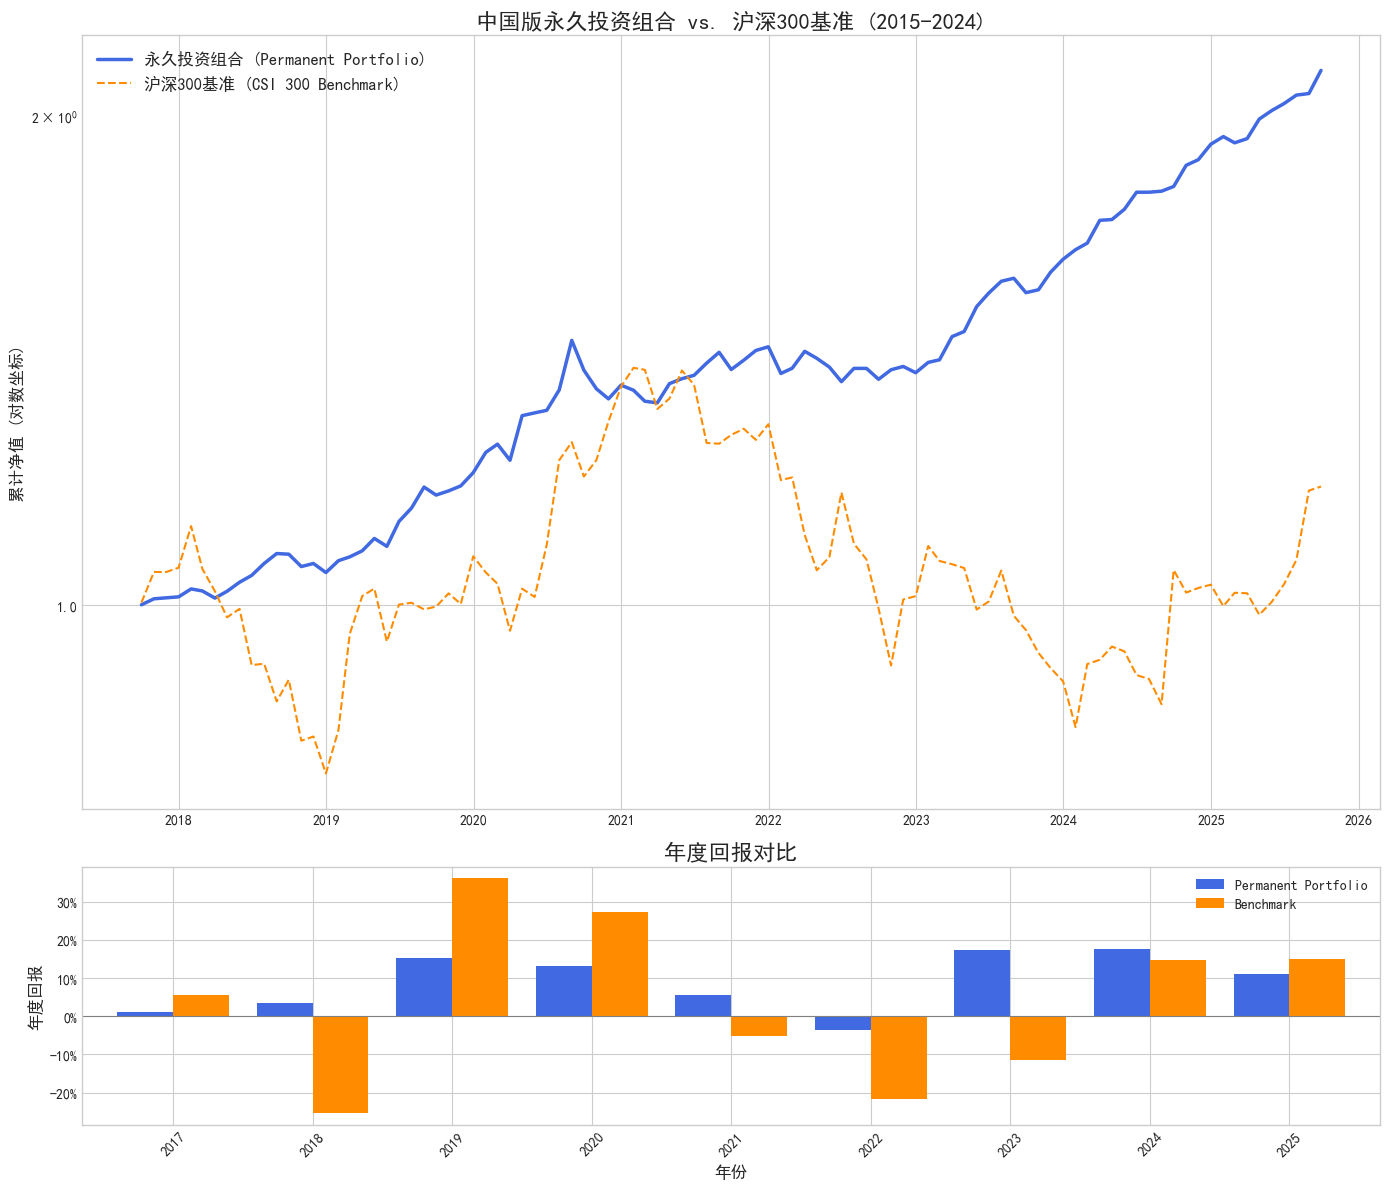

In [8]:
# 运行回测
run_akshare_permanent_portfolio_backtest()